In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
from models import CondSM
from tqdm import tqdm
import math
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [27]:
dataset_num = 0
dist_type = 'uni'
data_dir = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_{dist_type}_{dataset_num}/')
num_batches = 400
batch_size = 512
train_size = 0.8
val_size = 0.1
test_size = 0.1
output_idx = 0

In [28]:
voltages = []
currents = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])
        
vs = np.concatenate(voltages, axis=0)[..., [i for i in range(voltages[0].shape[1]) if i != output_idx]]
ys = np.concatenate(currents, axis=0)

V = torch.from_numpy(vs).float()
y = torch.from_numpy(ys).unsqueeze(-1).float()

print(V.shape)
print(y.shape)

dataset = TensorDataset(V, y)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

torch.manual_seed(123)
train_indices = train_ds.indices
V_noisy = V.clone()
noise_std = 0.05
V_noisy[train_indices] += torch.randn_like(V_noisy[train_indices]) * noise_std

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(test_loader.dataset)}")

torch.Size([200000, 7])
torch.Size([200000, 1])
train_set: 160000
val_set: 20000
test_set: 20000


In [24]:
def neg_ll(target, y):

    target = target.squeeze(-1)
    mu = y[..., 0]
    log_std = y[..., 1]
    
    N, d_out = y.shape

    sigma = F.softplus(log_std) + 1e-6
    var = sigma ** 2

    nll = 0.5 * ( 
        (target - mu) ** 2 / var 
        + 2 * torch.log(sigma) 
        + math.log(2 * math.pi) 
    )

    return nll.mean()

layer_dims = [7, 90, 90, 90, 2]
dp = 0.0
bn = False
model = CondSM(layer_dims, dropout_p=dp, batch_norm=bn)
model = model.to(device)
print('model loaded')

model loaded


In [25]:
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=1e-3
)

train_losses = []
val_losses = []

num_epochs = 500

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        model.train()
        running_loss = 0.0
        for v, y in train_loader:
            v = v.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True).float()
            
            optimizer.zero_grad()

            preds = model(v)
            
            loss = neg_ll(y, preds)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * v.size(0)
    
        epoch_train_loss = running_loss / len(train_loader.dataset)
    
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for v, y in val_loader:

                v = v.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()

                preds = model(v)

                loss = neg_ll(y, preds)
                
                val_loss += loss.item() * v.size(0)
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
    
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
        pbar.set_postfix({
            "epoch": f"{epoch}/{num_epochs}",
            "train": f"{epoch_train_loss:.4f}",
            "val": f"{epoch_val_loss:.4f}"
        })
        pbar.update(1)

torch.save({
    "model_state_dict": model.state_dict(),
    "layer_dims": layer_dims,
    "dropout": dp,
    "batch_norm": bn,
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_{dist_type}_{dataset_num}/sm_{dist_type}_{dataset_num}_baseline.pth")

print(f"Model has been saved!")

Epochs: 100%|██████████| 500/500 [06:40<00:00,  1.25it/s, epoch=500/500, train=-2.6196, val=-2.4657]

Model has been saved!


In [29]:
state_dict = torch.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_{dist_type}_{dataset_num}/sm_{dist_type}_{dataset_num}_baseline.pth", weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

val_losses = state_dict['val_losses']
train_losses = state_dict['train_losses']

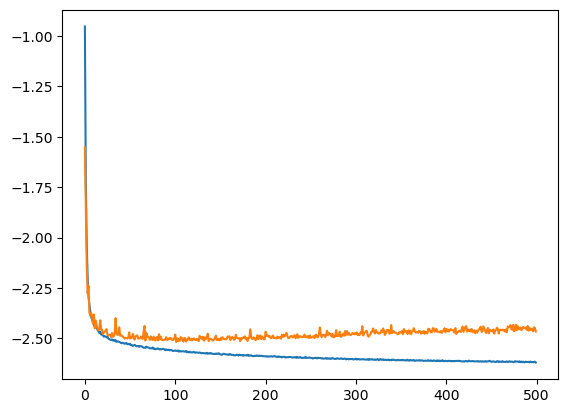

In [30]:
plt.plot(train_losses)
plt.plot(val_losses)

-0.28980032 0.2887971


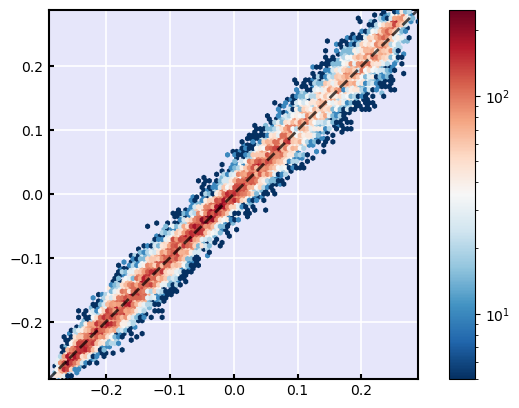

In [31]:
from utils import pred_vs_true

model.eval()
model = model.to(device)

pred_params = []
y_true_l = []
latent_l = []
with torch.no_grad():
    for v, y in test_loader:
        v = v.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()
        preds = model(v).detach().cpu().numpy()
        pred_params.append(preds)
        y_true_l.append(y.cpu().numpy())

y_pred_l = [params[..., 0] for params in pred_params]

from utils import pred_vs_true
from matplotlib.colors import LogNorm

y_pred = np.concatenate(y_pred_l, axis=0).ravel()
y_true = np.concatenate(y_true_l, axis=0).ravel()

lo = min(y_pred.min(), y_true.min())
hi = min(y_pred.max(), y_true.max())
print(lo, hi)
plot_range = [[lo, hi], [lo, hi]]

fig, ax = plt.subplots()

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

norm = LogNorm()

im = ax.hexbin(y_pred, y_true, bins=250, gridsize=100, norm=norm, cmap="RdBu_r", zorder=5)
#_, _, _, im = ax.hist2d(y_pred, y_true, bins=200, range=plot_range, norm=norm, cmap="RdBu", zorder=5)
ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=2, color='k', alpha=0.7, zorder=6)

fig = ax.figure
cax = fig.add_axes([ax.get_position().x1 - 0.05, ax.get_position().y0, 0.04, ax.get_position().height])
plt.colorbar(im, cax=cax)

ax.spines[:].set_linewidth(1.5)
ax.spines[:].set_facecolor('w')
ax.tick_params(direction='in', width=1.5)
ax.set_facecolor('lavender')
ax.grid(c='w', lw=1.2)

ax.set_aspect('equal', adjustable='box')

In [22]:
mse = ((y_true - y_pred) ** 2).mean()
rmse = np.sqrt(mse)
R_sq = 1 - mse / 
print(mse)
print(rmse)
print(y_true.min(), y_true.max(), y_true.std())

0.00044050722
0.020988263
-0.28980032 0.29038036 0.15098228


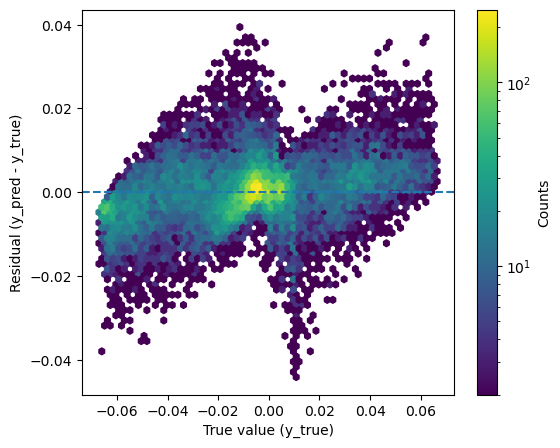

In [15]:
residuals = y_true - y_pred

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.hexbin(y_true, residuals, gridsize=60, norm=norm, mincnt=1)
ax.axhline(0.0, linestyle="--")
ax.set_xlabel("True value (y_true)")
ax.set_ylabel("Residual (y_pred - y_true)")
fig.colorbar(im, label="Counts")

(3054, 7)


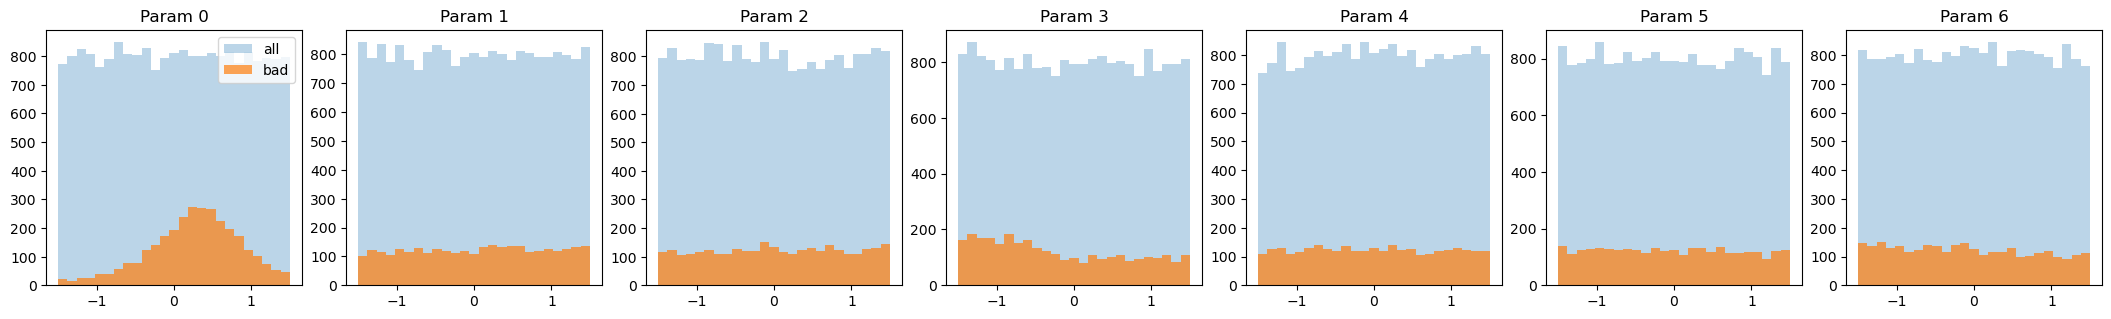

In [75]:
abs_err = np.abs(residuals)
bad_currents = abs_err > 0.01

X_test_params = np.concatenate([x for x, _ in test_loader], axis=0)

X_bad_params = X_test_params[bad_currents]
print(X_bad_params.shape)

bins = 25
ncols = X_test_params.shape[1]
fig, ax = plt.subplots(ncols=ncols, figsize=(3*ncols, 3), constrained_layout=True)

for i in range(ncols):
    # All points
    ax[i].hist(X_test_params[:, i], bins=bins, alpha=0.3, label="all")

    # Bad points
    ax[i].hist(X_bad_params[:, i], bins=bins, alpha=0.7, label="bad")

    ax[i].set_title(f"Param {i}")
    ax[i].set_box_aspect(1)

ax[0].legend()
plt.show()
